## Oppagve 1

Selskapet IntCom er en internettleverandør. Selskapet sørger for overføring av data mellom kundene og internett. Datatrafikken varierer gjennom døgnet.<br>
Tabellen nedenfor viser datatrafikken (gigabit per time) er døgn i mai.
<table style="border-collapse: collapse; border: 2px solid black;">
<tr>
<th style="background-color: lightgreen; border: 2px solid black; padding: 6px;">Tidspunkt <br>(klokkeslett)</th>
<td style="border: 2px solid black; padding: 6px;">00:00</td>
<td style="border: 2px solid black; padding: 6px;">02:00</td>
<td style="border: 2px solid black; padding: 6px;">06:00</td>
<td style="border: 2px solid black; padding: 6px;">08:00</td>
<td style="border: 2px solid black; padding: 6px;">12:00</td>
<td style="border: 2px solid black; padding: 6px;">16:00</td>
<td style="border: 2px solid black; padding: 6px;">20:00</td>
<td style="border: 2px solid black; padding: 6px;">22:00</td>
</tr>

<tr>
<th style="background-color: lightgreen; border: 2px solid black; padding: 6px;">Datatrafikk <br> (gigabit per time)</th>
<td style="border: 2px solid black; padding: 6px;">58280</td>
<td style="border: 2px solid black; padding: 6px;">29400</td>
<td style="border: 2px solid black; padding: 6px;">22550</td>
<td style="border: 2px solid black; padding: 6px;">32200</td>
<td style="border: 2px solid black; padding: 6px;">67450</td>
<td style="border: 2px solid black; padding: 6px;">86110</td>
<td style="border: 2px solid black; padding: 6px;">102007</td>
<td style="border: 2px solid black; padding: 6px;">87810</td>
</tr>
</table>

a) Lag en god modell for datatrafikken S(t) gigabit per time , $t$ timer etter midnatt dette døgnet

### Løsning

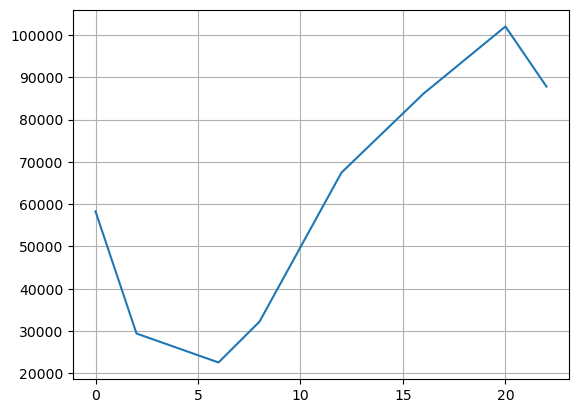

In [40]:
import matplotlib.pyplot as plt

Tidspunkt=[0,2,6,8,12,16,20,22]
Datatrafikk=[58280,29400,22550,32200,67450,86110,102007,87810]

plt.plot(Tidspunkt,Datatrafikk)
plt.grid()
plt.show()

Ut fra grafen over så antar at $S(t)$ er en trigonometrisk funksjon på formen ($A\sin(ct+\varphi)+d$)<br>
Gjør en regresjon på denne formen.


In [42]:
import scipy.optimize as sct
import numpy as np

Tidspunkt=[0,2,6,8,12,16,20,22]
Datatrafikk=[58280,29400,22550,32200,67450,86110,102007,87810]

def f(t,a,c,phi,d):
    return a*np.sin(c*t+phi)+d

[a,c,phi,d]=sct.curve_fit(f,Tidspunkt,Datatrafikk)[0]
print(f"S(t)={a}*sin({c}t+{phi})+{d}")

S(t)=-39456.372019665796*sin(-45.10452829345762t+-191.6838616900335)+64971.03712208629


<div style="background-color:#e6f7e6; padding:10px;">
$S(t)=-39456\cdot\sin(-45t-192)+64971$
</div>

Videre i oppgaven skal du bruke modellen
$$\begin{align*}
D(t)=63000+37000\cdot \sin(0.24t-3.0)
\end{align*}$$
for datatrafikken $D(t)$, $t$ timer etter midnatt dette døgnet. 

b) Når var datatrafikken ut fra selskapet mer enn 90000 gigabit per time ifølge modellen?

### Løsning

In [38]:
import numpy as np

def D(t):
    return 63000+37000*np.sin(0.24*t-3.0)
t=0
while D(t)<90000:
   t=t+0.001
   
print(f"Rundt klokken {round(t)} var datatrafikken over 90000 Gb/h")

Rundt klokken 16 var datatrafikken over 90000 Gb/h


<div style="background-color:#e6f7e6; padding:10px;">
Rundt klokken 16 var datatrafikken over $90000$ Gigabit per time
</div>

c) Når økte datatrafikken raskest, og hvor stor var denne økningen i følge modellen?

### Løsning

In [43]:
import sympy as sp
t=sp.symbols("t")
def Data(t):
    return 63000+37000*sp.sin(0.24*t-3.0)

derivert=sp.diff(Data(t),t)

losning=sp.solve(derivert,t)
print(losning) #Forkaster losning 2 (32.13)
print("Forkaster løsning 2 (32.13495) da denne er utenfor modellen (0-24)")
a=losning[0]
print(f"Det økte raskest rundt kl.{round(a)}, da var økningen {round(Data(a))} Gb\h^2")

[19.0449846949787, 32.1349540849362]
Forkaster løsning 2 (32.13495) da denne er utenfor modellen (0-24)
Det økte raskest rundt kl.19, da var økningen 100000 Gb\h^2


<div style="background-color:#e6f7e6; padding:10px;">
Det økte raskest rundt kl.19, da var økningen $100000$ Gigabit per time per time ($Gb/h^2$)
</div>

d) Hvor stor del av den totale datamengden som IntCom overførte dette døgnet ble overført i løpet av arbeidsdagen, det vil si mellom klokken 8 og klokken 16, i følge modellen?

### Løsning

In [44]:
import sympy as sp
t=sp.symbols("t")
def Data(t):
    return 63000+37000*sp.sin(0.24*t-3.0)

total=sp.integrate(Data(t),(t,8,16))
print(f"Den totale datamengden mellom kl. 8 og 16 var ca. {round(total,1)} Gb")
total_døgn=sp.integrate(Data(t),(t,0,24))
print(f"Dette utgjør {round((total/total_døgn),3)*100}% av den totale datatrafikken på {total_døgn} Gb")

Den totale datamengden mellom kl. 8 og 16 var ca. 473762.6 Gb
Dette utgjør 31.5% av den totale datatrafikken på 1502454.03293137 Gb


<div style="background-color:#e6f7e6; padding:10px;">
$31.5 \%$ av den totale datatmengden ble overført i løpet av arbeidsdagen.
</div>

## Oppgave 2

En undeleig rekke er gitt ved den rekursive sammenhengen
$$\begin{align*}
&a_n=(a_{n-a}-1)^2
\end{align*}$$

a) Lag et program som skriver ut de 6 første leddene i rekken dersom $a_1=5$

### Løsning

In [33]:
def rekursiv(a):
    return(a-1)**2

a=5
for i in range(1,7):
    print(f"a{i}={a}")
    a=rekursiv(a)
    

a1=5
a2=16
a3=225
a4=50176
a5=2517530625
a6=6337960442777829376


b) Avgjør om det finnes et heltall $a_1$ som at denne rekken blir konvergent

### Løsning

Et hvert heltall $a_1$ vi setter inn $a_2=(a_1-1)^2$ vil gi et naturlig tall ut. <br>
Altså vil $a_1=-1$ gi $a_2=4$ og vi vil stadig få høyere tall slik som i oppgave a <br>
Derfor lager jeg et python program som sjekker $a_1$ fra 0 til 3, og de 5 første leddene

In [27]:
def rekursiv(a):
    return (a-1)**2

for a in range(0,4):
    print("")
    print(f"a_1={a}")

    for i in range(1,6):
        print(i,a)
        a=rekursiv(a)


a_1=0
1 0
2 1
3 0
4 1
5 0

a_1=1
1 1
2 0
3 1
4 0
5 1

a_1=2
1 2
2 1
3 0
4 1
5 0

a_1=3
1 3
2 4
3 9
4 64
5 3969


Allerede fra $a_1=3$ så går øker leddene i følgen rett til værs raskt, så $a_1$ må være lavere.<br> 
Vi ser at $a_1=0$, $a_1=1$ og $a_1=2$ gir et alternerende mønster $0,1,0,\cdots $ eller $1,0,1,\cdots$ <br>
I oppgaven står det esksplitt ordet"rekke" ("Avgjør om det finnes et heltall $a_1$ som at denne rekken blir konvergent"). Siden vi ikke har noen rekke antar jeg at jeg skal summere leddene i følgen, jeg har ikke blitt spurt om følgen i oppgaven så jeg må tolke det dit hen at en rekke er det som ønskes.<br>

Siden oppgaven er uklar på hva den egentlig mener velger jeg å gi to løsninger.<br>
<div style="background-color:#e6f7e6; padding:10px;">
Som rekke:<br>
Hvis dette skal være en rekke det betyr at vi må summere alt og selv $0+1+0+1+\cdots$ vil divergere, så det finnes ingen heltall $a_1$ som gjør at rekka konvergerer.
<br>
Som følge:<br>
Vi ser at for alle $a_1$ bortsett fra $0,1,2$ så vokser $a_n$ eneormt for hvert ledd. For $0,1,2$ får vi en alternerende svinging mellom $0$ og $1$, den nærmer seg dermed ikke verdi en bestemt verdi, for noen heltall $a_1$.
</div>

## Oppgave 3

Et lite propellfly må nødlande på en motorvei. Posisjonen $\vec{r}(t)$ til flyet $t$ sekunder etter at nødlandingen har startet, er gitt ved
$$\begin{align*}
\vec{r}(t)=\left[30t-t^2,8\sin \left(\displaystyle\frac{\pi}{10}t \right),50 \left(1-\displaystyle\frac{t}{10} \right)^2 \right]
\end{align*}$$
Motorveien ligger i  xy-planet. <br>
Enhetene langs aksene er meter.

a) Hvor høyt over motorveien er flyet 4 sekunder etter at nødlandingen har startet?

### Løsning

In [10]:
import numpy as np
def r(t):
    r=np.array([30*t-t**2,8*np.sin(np.pi/10)*t,50*(1-(t/10))**2])
    return r

print(f"Flyet er da {r(4)[2]} meter over motorveien")

Flyet er da 18.0 meter over motorveien


<div style="background-color:#e6f7e6; padding:10px;">
Flyet er da $18.0$ meter over motorveien
</div>

b) Bestem banefarten idet flyet lander på motorveien.

Vi deriverer $\vec{r}(t)$ og får 
$\vec{v}(t)=\left[30-2t,\displaystyle\frac{4\pi}{5}\cos \left(\displaystyle\frac{\pi}{10}t \right),t-10 \right]$

In [12]:
def v(t):
    v=np.array([30-2*t,(4*np.pi/5)*np.cos((np.pi*t/10)),t-10])
    return v
t=0
while v(t)[2]<=0:
    t=t+0.0001

banefart=np.linalg.norm(v(t))
print(f"Banefarten til flyet i det det lander er {round(banefart,2)} m/s")

Banefarten til flyet i det det lander er 10.31 m/s


<div style="background-color:#e6f7e6; padding:10px;">
Banefarten til flyet i det det lander er $10.31$ m/s
</div>

c) Ved hvilket tidspunkt under nødlandingen er banefarten $14,3$ m/s?

In [45]:
def v(t):
    v=np.array([30-2*t,(4*np.pi/5)*np.cos((np.pi*t/10)),t-10])
    return v
    
t=0
while np.linalg.norm(v(t))>=14.3:
    t=t+0.0001

print(f"Banefarten til flyet er 14,3 m/s etter ca. {round(t,1)} sekunder")
    


Banefarten til flyet er 14,3 m/s etter ca. 8.0 sekunder


<div style="background-color:#e6f7e6; padding:10px;">
Banefarten til flyet er $14,3$ m/s etter ca. $8.0$ sekunder
</div>

En fugl er posisjonen $(131,67,23)$  idet flyet starter nødlandingen. 
Fuglen flyr i en rett linje og krysser banen til flyet i punktet $\left(125,8,\displaystyle\frac{25}{2} \right)$

Fuglen holder en jevn banefart på $12$ m/s

d) Vil fuglen treffe flyet?

In [16]:
import numpy as np
def r(t):
    r=np.array([30*t-t**2,8*np.sin(np.pi/10)*t,50*(1-(t/10))**2])
    return r

Fugl_start=np.array([131,67,23])
Fly_posisjon=np.array([125,8,25/2])
fugl_fart=12

avstand_vektor=(Fugl_start-Fly_posisjon)
avstand=(np.linalg.norm(avstand_vektor))

t=avstand/fugl_fart

print(f"Etter {round(t)} sekunder er flyet på posisjon {r(t)}")


Etter 5 sekunder er flyet på posisjon [125.37740196  12.40737332  12.4057387 ]


<div style="background-color:#e6f7e6; padding:10px;">
Vi ser at flyet og fuglen er på omtrent samme $x$-koordiant og $z$-koordinat.<br>
Men $y$-koordinat er $4,4$ meter unna. Det som avhenger er vingelengden til fuglen og propellradiusen til flyet. 
Er propellradiusen maks. $3$ meter og fuglens vingelengde er maks. $1$ meter så treffer ikke fuglen flyet.
</div>

## Oppgave 4

Du får i oppdrag å lage en vase med form som på bildet nedenfor.<br>
Vasen skal rommen omtrent $1,5$ L vann og ha en høyden $20$ cm.

Bruk det du kan om omfreiningslegemenr og trigonometri, til å lage en funksjon på formen
$$\begin{align*}
f(x)=A\cdot \sin (cx+\varphi)+d
\end{align*}$$
som ved omdreining gir en vase denne formen.

Tegn grafen til funkjsonen i et koordinatsystem der enhetene langs aksene er centimeter. 

Husk å begrunne tydelig ditt valg av parameterne $A,c,\varphi$ og $d$, og la funksjonsuttrykket komme tydelig frem i besvarelsen din.

### Løsning

Vi kan starte med å finne perioden $p$ den vil være $20$ siden det er høyden på vasen. (vasen går går som en tilnærmet bølge fra bunnen opp til toppen av vasen).<br>
Fra dette kan vi regne $c=\displaystyle\frac{2\pi}{p}=\displaystyle\frac{2\pi}{20}=\displaystyle\frac{\pi}{10}$

Når grafen er på sitt høyeste (vasens tykkeste del) er $\sin (cx+\varphi)=1$, da står vi igjen med $f(x)=A+d$<br>
Når grafen er på sitt laveste (vasens smalleste del) er $\sin (cx+\varphi)=-1$, da står vi igjen med $f(x)=-A+d$<br>
Den tykkeste delen er omtrent midt på vasen altså ved $x=10$, dermed er:<br>
$\sin (c\cdot 10+\varphi)=\sin \left(\displaystyle\frac{\pi}{\cancel{10}}\cdot \cancel{10}+\varphi \right)=1 \Rightarrow \pi+\varphi=\sin^{-1}(1)=\displaystyle\frac{\pi}{2} \Rightarrow \varphi=-\displaystyle\frac{\pi}{2}$<br>


Volumet er $\pi \displaystyle\int_0^{20} (f(x))^2 \,dx=1500$<br>
$\displaystyle\int_0^{20} \left(A\sin \left(\displaystyle\frac{\pi}{10}x-\displaystyle\frac{\pi}{2} \right)+d \right)^2 \,dx=10A^2+20d^2$<br>
$10A^2+20d^2=\displaystyle\frac{1500}{\pi} \Rightarrow d=\sqrt{\displaystyle\frac{75}{\pi}-\displaystyle\frac{A^2}{2}}$<br>

Jeg velger finne A gjennomå sjekke ulike verdier for A i et numerisk integral, der jeg sammenligner $\displaystyle\int_0^{20} (f(x))^2\,dx$ mot $\displaystyle\frac{1500}{\pi}$<br>
Hvis $\displaystyle\int_0^{20} (f(x))^2\,dx-\displaystyle\frac{1500}{\pi}\approx 0$, vet jeg at jeg har funner en $A$ som passer og dermed også $d$ fordi $d=\sqrt{\displaystyle\frac{75}{\pi}-\displaystyle\frac{A^2}{2}}$ 


f(x)=0.001sin(0.3141592653589793x+-1.5707963267948966)+4.886025119029199


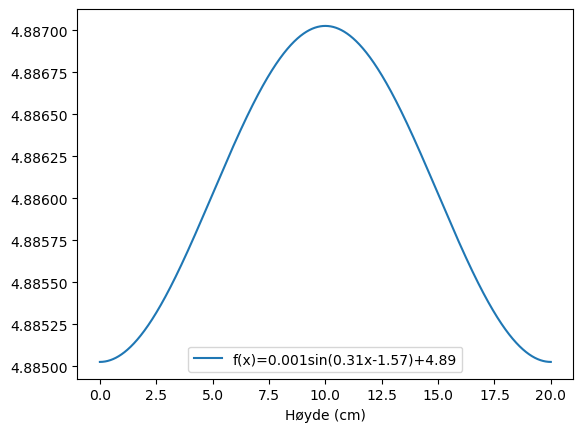

In [31]:
import numpy as np
import matplotlib.pyplot as plt
pi=np.pi

def f(t):
    return A*np.sin(c*t+phi)+d
def simpsons_regel(f,a,b,n):
    
    if n%2==1 or n<0:
        t=("ingen riktig løsning, n nå være partall større enn 0")
        return t
    
    delta_x=(b-a)/n
    x=np.linspace(a,b,n+1)
    fx=f(x)**2
    
    #Simpson formel
    integral=(delta_x/3)*(fx[0]+fx[-1]+4*np.sum(fx[1:-1:2])+2*np.sum(fx[2:-2:2]))
    
    return integral

a=0
b=20
n=4000 #må være partall

A=0 #Plassholder blir endret i while løkken under
c=pi/10
phi=-pi/2
d=np.sqrt(75/pi-A**2/2)
#resultat=simpsons_regel(f,a,b,n)

while abs(simpsons_regel(f,a,b,n)-1500/pi)<0.000001:
    A=A+0.001
    print(f"f(x)={A}sin({c}x+{phi})+{d}")

x=np.linspace(a,b,n+1)

plt.plot(x,f(x),label=f"f(x)={A}sin({round(c,2)}x{round(phi,2)})+{round(d,2)}")
plt.xlabel("Høyde (cm)")
plt.xlabel("Høyde (cm)")
plt.legend()
plt.show()

$f(x)=0.001\sin \left(\displaystyle\frac{\pi}{10}\cdot x-\displaystyle\frac{\pi}{2} \right)+\sqrt{\displaystyle\frac{75}{\pi}-\displaystyle\frac{1}{20000}}$